# Section 3

In [1]:
import sqlite3
import pandas as pd

df = pd.read_csv('team_traditional.csv')
conn = sqlite3.connect('capstone.db')
df.to_sql('team_traditional', conn, if_exists='replace', index=False)

query = "SELECT * FROM team_traditional WHERE season = 2025 AND type = 'regular'"
df_2025 = pd.read_sql(query, conn)
print(len(df_2025))
df_2025.head()

2460


,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
0,22400061,2024-10-22,regular,1610612738,BOS,BOS,NYK,48.0,132.0,48.0,...,29.0,40.0,33.0,4.0,6.0,3.0,15.0,23.0,1.0,2025
1,22400061,2024-10-22,regular,1610612752,NYK,BOS,NYK,48.0,109.0,43.0,...,29.0,34.0,20.0,12.0,2.0,3.0,12.0,-23.0,0.0,2025
2,22400062,2024-10-22,regular,1610612747,LAL,LAL,MIN,48.0,110.0,42.0,...,31.0,46.0,22.0,7.0,7.0,8.0,22.0,7.0,1.0,2025
3,22400062,2024-10-22,regular,1610612750,MIN,LAL,MIN,48.0,103.0,35.0,...,35.0,47.0,17.0,16.0,4.0,1.0,22.0,-7.0,0.0,2025
4,22400063,2024-10-23,regular,1610612754,IND,DET,IND,48.0,115.0,42.0,...,32.0,39.0,32.0,15.0,10.0,8.0,23.0,6.0,1.0,2025


In [2]:
df_2025.isnull().sum()
print((df_2025.isnull().sum() / len(df_2025)) * 100)

gameid    0.0
date      0.0
type      0.0
teamid    0.0
team      0.0
home      0.0
away      0.0
MIN       0.0
PTS       0.0
FGM       0.0
FGA       0.0
FG%       0.0
3PM       0.0
3PA       0.0
3P%       0.0
FTM       0.0
FTA       0.0
FT%       0.0
OREB      0.0
DREB      0.0
REB       0.0
AST       0.0
TOV       0.0
STL       0.0
BLK       0.0
PF        0.0
+/-       0.0
win       0.0
season    0.0
dtype: float64


These histograms show the distribution of each core team statistic (points, shooting percentages, rebounds, assists, turnovers, steals, blocks) across all 2025 games. Most stats appear roughly normal with no extreme outliers, confirming they're reasonable candidates for the rolling averages built later.

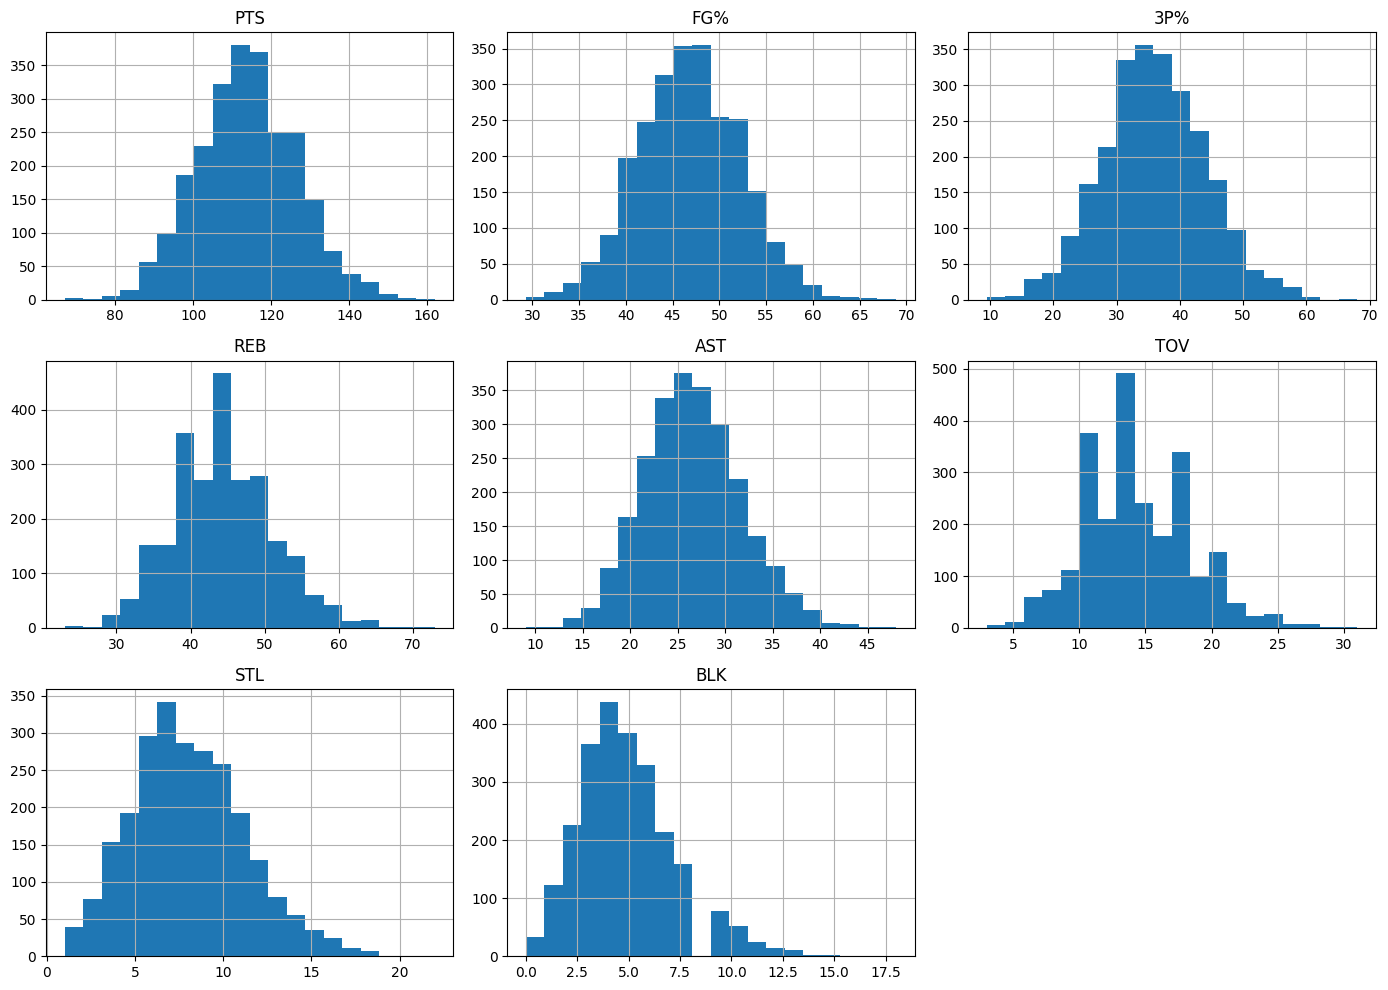

In [3]:
import matplotlib.pyplot as plt

stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']
df_2025[stats].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

This heatmap shows how each raw box score statistic relates to every other statistic and to win. It also reveals redundancy between related stats (e.g., FGM and FGA both tied to FG%), which informed later feature choices.

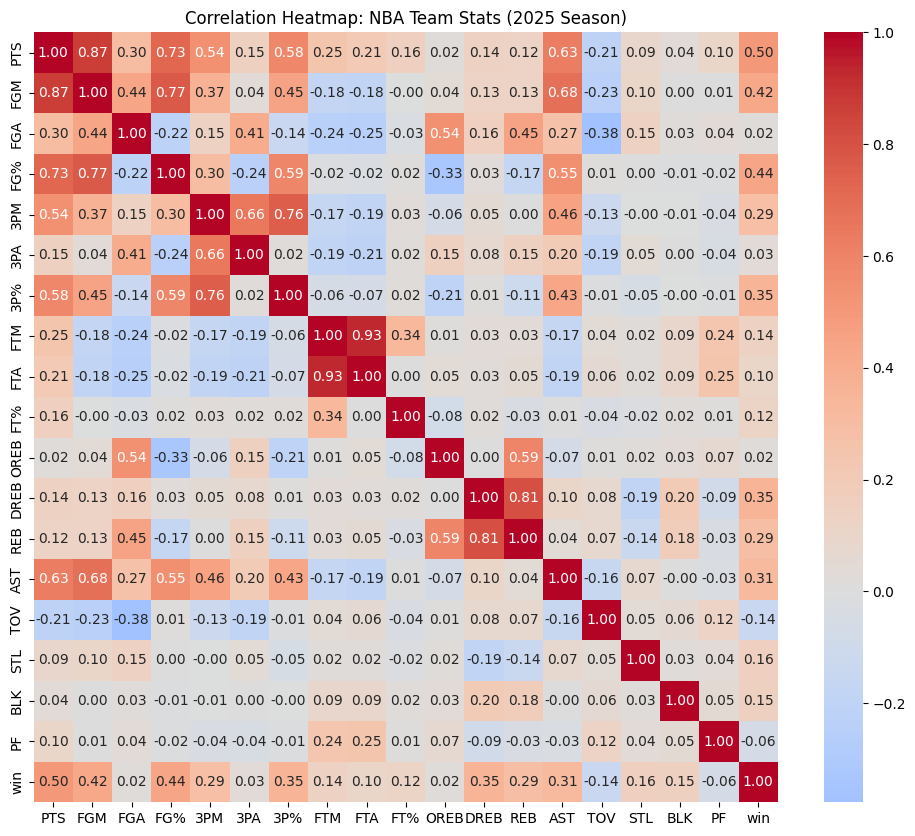

In [4]:
import seaborn as sns

statistics = ['PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%',
              'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'win']
plt.figure(figsize=(12, 10))
sns.heatmap(df_2025[statistics].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: NBA Team Stats (2025 Season)')
plt.show()

This bar chart shows the distribution of the target variable, win, which is exactly balanced at 50% each, since every game produces one winning and one losing team. This confirms no resampling or class weighting was needed for the baseline model.

win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


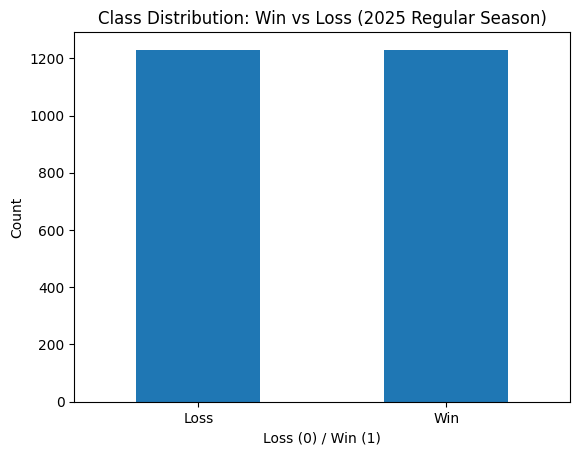

In [5]:
print(df_2025['win'].value_counts(normalize=True))

df_2025['win'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution: Win vs Loss (2025 Regular Season)')
plt.xlabel('Loss (0) / Win (1)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Loss', 'Win'], rotation=0)
plt.show()

Feature Engineering

In [6]:
df_2025['date'] = pd.to_datetime(df_2025['date'])
df_2025 = df_2025.sort_values(['team', 'date']).reset_index(drop=True)

df_2025['opponent'] = df_2025.apply(lambda r: r['away'] if r['team']==r['home'] else r['home'], axis=1)
df_2025['is_home'] = (df_2025['team'] == df_2025['home']).astype(int)
df_2025['rest_days'] = df_2025.groupby('team')['date'].diff().dt.days

window_sizes = [5, 10, 15, 20, 25]
for w in window_sizes:
    for s in stats:
        shifted = df_2025.groupby('team')[s].shift(1)
        df_2025[f'{s}_roll{w}'] = shifted.groupby(df_2025['team']).rolling(w, min_periods=2).mean().reset_index(drop=True)

In [7]:
feature_cols_all = [f'{s}_roll{w}' for s in stats for w in window_sizes] + ['is_home', 'rest_days']
id_cols = ['gameid', 'date', 'team']

df_model2 = df_2025[id_cols + feature_cols_all + ['win']].dropna(subset=feature_cols_all).reset_index(drop=True)
df_model2 = df_model2.sort_values('date').reset_index(drop=True)

print(df_model2.shape)
print(df_model2.columns.tolist())

(2400, 46)
['gameid', 'date', 'team', 'PTS_roll5', 'PTS_roll10', 'PTS_roll15', 'PTS_roll20', 'PTS_roll25', 'FG%_roll5', 'FG%_roll10', 'FG%_roll15', 'FG%_roll20', 'FG%_roll25', '3P%_roll5', '3P%_roll10', '3P%_roll15', '3P%_roll20', '3P%_roll25', 'REB_roll5', 'REB_roll10', 'REB_roll15', 'REB_roll20', 'REB_roll25', 'AST_roll5', 'AST_roll10', 'AST_roll15', 'AST_roll20', 'AST_roll25', 'TOV_roll5', 'TOV_roll10', 'TOV_roll15', 'TOV_roll20', 'TOV_roll25', 'STL_roll5', 'STL_roll10', 'STL_roll15', 'STL_roll20', 'STL_roll25', 'BLK_roll5', 'BLK_roll10', 'BLK_roll15', 'BLK_roll20', 'BLK_roll25', 'is_home', 'rest_days', 'win']


Before building my actual baseline model, I treated the rolling window length itself as a parameter to test, rather than picking a fixed number upfront. I used an LLM (Claude) to help aid me in  training a simple, untuned Logistic Regression model separately on each of the rolling averages including the new ones I created, holding everything else identical (same train/test split, same model settings) so window size was the only variable changing between tests. I compared each version on accuracy and ROC-AUC, then selected the best-performing window size for my final feature set going forward.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

split_idx2 = int(len(df_model2) * 0.8)
train2, test2 = df_model2.iloc[:split_idx2], df_model2.iloc[split_idx2:]

for w in window_sizes:
    feats = [c for c in feature_cols_all if f'roll{w}' in c] + ['is_home', 'rest_days']
    feats = list(dict.fromkeys(feats))

    X_tr, X_te = train2[feats], test2[feats]
    y_tr, y_te = train2['win'], test2['win']

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    m = LogisticRegression(random_state=42, max_iter=1000)
    m.fit(X_tr_s, y_tr)
    pred = m.predict(X_te_s)
    proba = m.predict_proba(X_te_s)[:, 1]

    print(f"{w}-game window: accuracy={accuracy_score(y_te, pred):.4f}, ROC-AUC={roc_auc_score(y_te, proba):.4f}")

5-game window: accuracy=0.6000, ROC-AUC=0.6488
10-game window: accuracy=0.6042, ROC-AUC=0.6565
15-game window: accuracy=0.6146, ROC-AUC=0.6511
20-game window: accuracy=0.6208, ROC-AUC=0.6637
25-game window: accuracy=0.5958, ROC-AUC=0.6561


In [9]:
feature_cols = [f'{s}_roll20' for s in stats] + ['is_home', 'rest_days']
id_cols = ['gameid', 'date', 'team', 'opponent']

df_model_final = df_2025[id_cols + feature_cols + ['win']].dropna(subset=feature_cols).reset_index(drop=True)
df_model_final = df_model_final.sort_values('date').reset_index(drop=True)
print(df_model_final.shape)

(2400, 15)


Preprocessing Impact

In [10]:
print(f"Rows before dropping early-season rows: {len(df_2025)}")
print(f"Rows after dropping early-season rows: {len(df_model_final)}")

print("\nMissing values before (raw stats):", df_2025[stats].isnull().sum().sum())
print("Missing values after (feature columns):", df_model_final[feature_cols].isnull().sum().sum())

print("\nClass balance before:")
print(df_2025['win'].value_counts(normalize=True))
print("\nClass balance after:")
print(df_model_final['win'].value_counts(normalize=True))

Rows before dropping early-season rows: 2460
Rows after dropping early-season rows: 2400

Missing values before (raw stats): 0
Missing values after (feature columns): 0

Class balance before:
win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Class balance after:
win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


This before/after comparison shows raw single-game points versus the 20-game rolling average. The rolling version is visibly narrower and more centered, since averaging across games smooths out game-to-game noise, confirming the rolling features reflect recent team form rather than any single unusual performance.

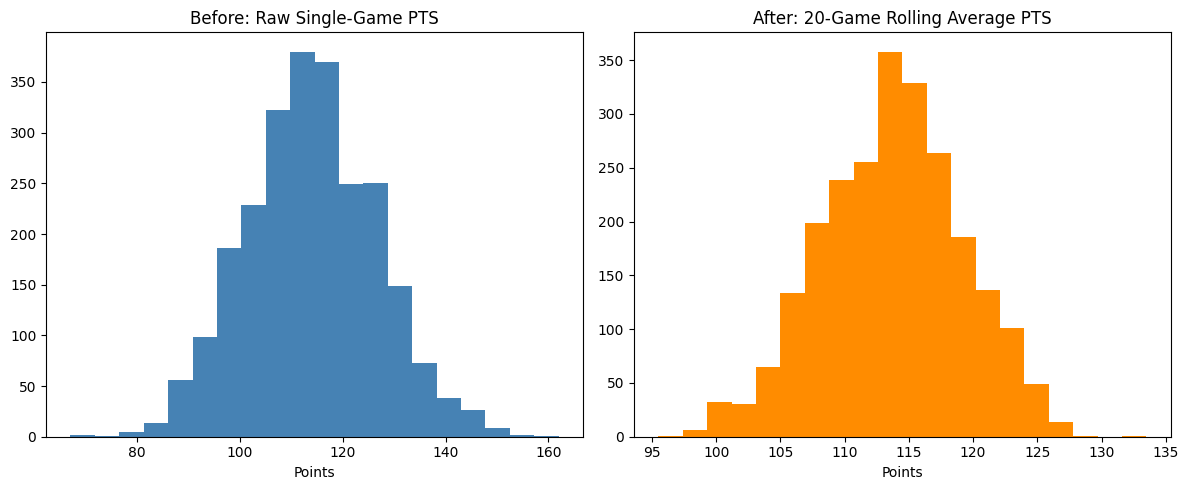

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df_2025['PTS'], bins=20, color='steelblue')
axes[0].set_title('Before: Raw Single-Game PTS')
axes[0].set_xlabel('Points')
axes[1].hist(df_model_final['PTS_roll20'], bins=20, color='darkorange')
axes[1].set_title('After: 20-Game Rolling Average PTS')
axes[1].set_xlabel('Points')
plt.tight_layout()
plt.show()

In [12]:
pd.set_option('display.max_columns', None)
df_model_final.describe()

,gameid,date,PTS_roll20,FG%_roll20,3P%_roll20,REB_roll20,AST_roll20,TOV_roll20,STL_roll20,BLK_roll20,is_home,rest_days,win
count,2.400000e+03,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,2.240063e+07,2025-01-19 21:52:48,113.699926,46.674008,35.871098,44.121466,26.425758,14.418537,8.228199,4.977714,0.498333,2.122500,0.500000
min,2.240000e+07,2024-10-26 00:00:00,95.500000,37.950000,19.500000,35.000000,17.250000,9.000000,3.500000,1.500000,0.000000,1.000000,0.000000
25%,2.240033e+07,2024-12-05 00:00:00,109.850000,45.253750,34.425000,42.500000,24.850000,13.300000,7.450000,4.400000,0.000000,2.000000,0.000000
50%,2.240063e+07,2025-01-20 00:00:00,113.900000,46.727500,35.940000,44.100000,26.300000,14.300000,8.100000,4.900000,0.000000,2.000000,0.500000
75%,2.240093e+07,2025-03-06 00:00:00,117.500000,48.267500,37.600000,45.754808,28.200000,15.500000,8.900000,5.450000,1.000000,2.000000,1.000000
max,2.240123e+07,2025-04-13 00:00:00,133.500000,54.900000,43.700000,58.500000,36.500000,23.000000,14.000000,10.000000,1.000000,9.000000,1.000000
std,3.490163e+02,NaN,5.499381,2.251966,2.505680,2.504444,2.465716,1.609293,1.217596,0.908529,0.500101,1.007679,0.500104


In [13]:
print(df_model_final['team'].value_counts())
print()
print(df_model_final['opponent'].value_counts())
print()
print(df_model_final['is_home'].value_counts())

team
MIN    80
PHX    80
DET    80
BOS    80
ORL    80
CHA    80
MEM    80
HOU    80
CHI    80
LAL    80
CLE    80
TOR    80
ATL    80
LAC    80
NOP    80
MIL    80
OKC    80
PHI    80
IND    80
BKN    80
GSW    80
POR    80
DAL    80
SAC    80
NYK    80
UTA    80
WAS    80
MIA    80
DEN    80
SAS    80
Name: count, dtype: int64

opponent
DAL    81
MIA    81
WAS    81
SAC    81
OKC    81
SAS    81
MEM    80
DET    80
BOS    80
TOR    80
ORL    80
MIN    80
GSW    80
POR    80
BKN    80
ATL    80
IND    80
PHI    80
MIL    80
LAC    80
NOP    80
UTA    80
NYK    80
DEN    80
CHI    79
CLE    79
HOU    79
PHX    79
LAL    79
CHA    79
Name: count, dtype: int64

is_home
0    1204
1    1196
Name: count, dtype: int64


In [14]:
Q1 = df_model_final[feature_cols].quantile(0.25)
Q3 = df_model_final[feature_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = {}
for col in feature_cols:
    outliers = df_model_final[(df_model_final[col] < lower_bound[col]) | (df_model_final[col] > upper_bound[col])]
    outlier_counts[col] = len(outliers)

pd.Series(outlier_counts).sort_values(ascending=False)

,0
rest_days,901
STL_roll20,70
BLK_roll20,65
3P%_roll20,41
REB_roll20,40
TOV_roll20,21
FG%_roll20,19
AST_roll20,10
PTS_roll20,5
is_home,0


These boxplots show the spread and outliers for each of the 10 final features. Most stats show a handful of outliers consistent with legitimate blowout or unusual games rather than data errors, matching the IQR check performed earlier.

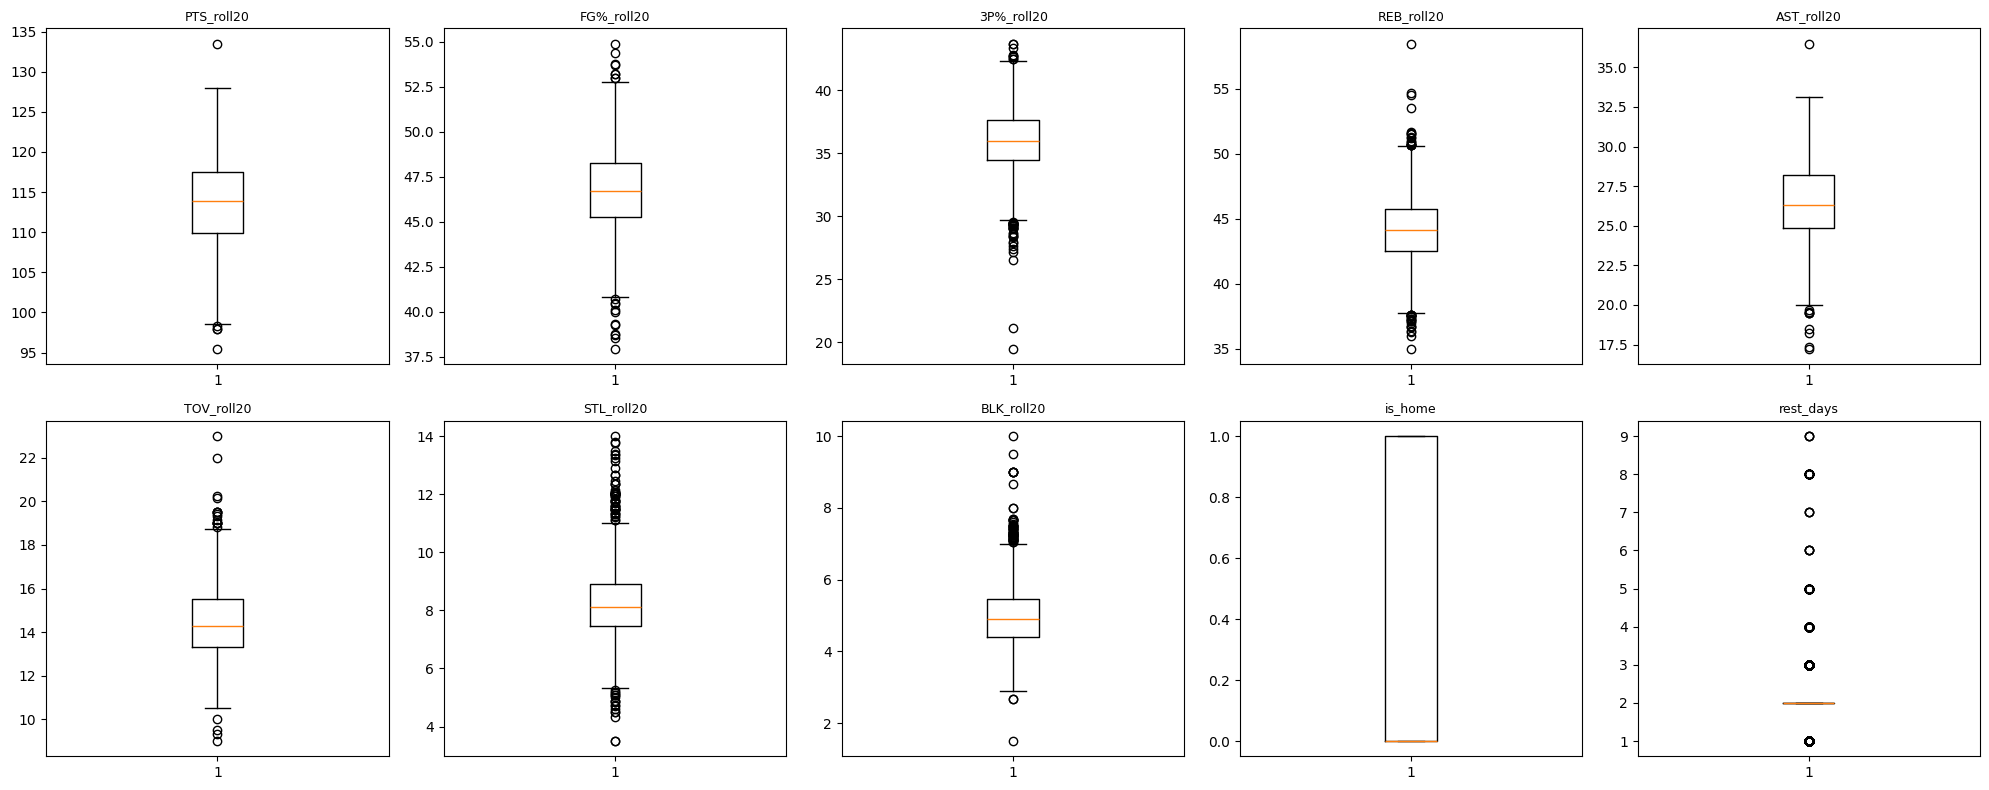

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].boxplot(df_model_final[col].dropna())
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

These histograms show the distribution of each final rolling feature (20-game averages, home/away, rest days). Most are roughly normal and free of extreme skew, confirming they're reasonable, well-behaved inputs for the model.

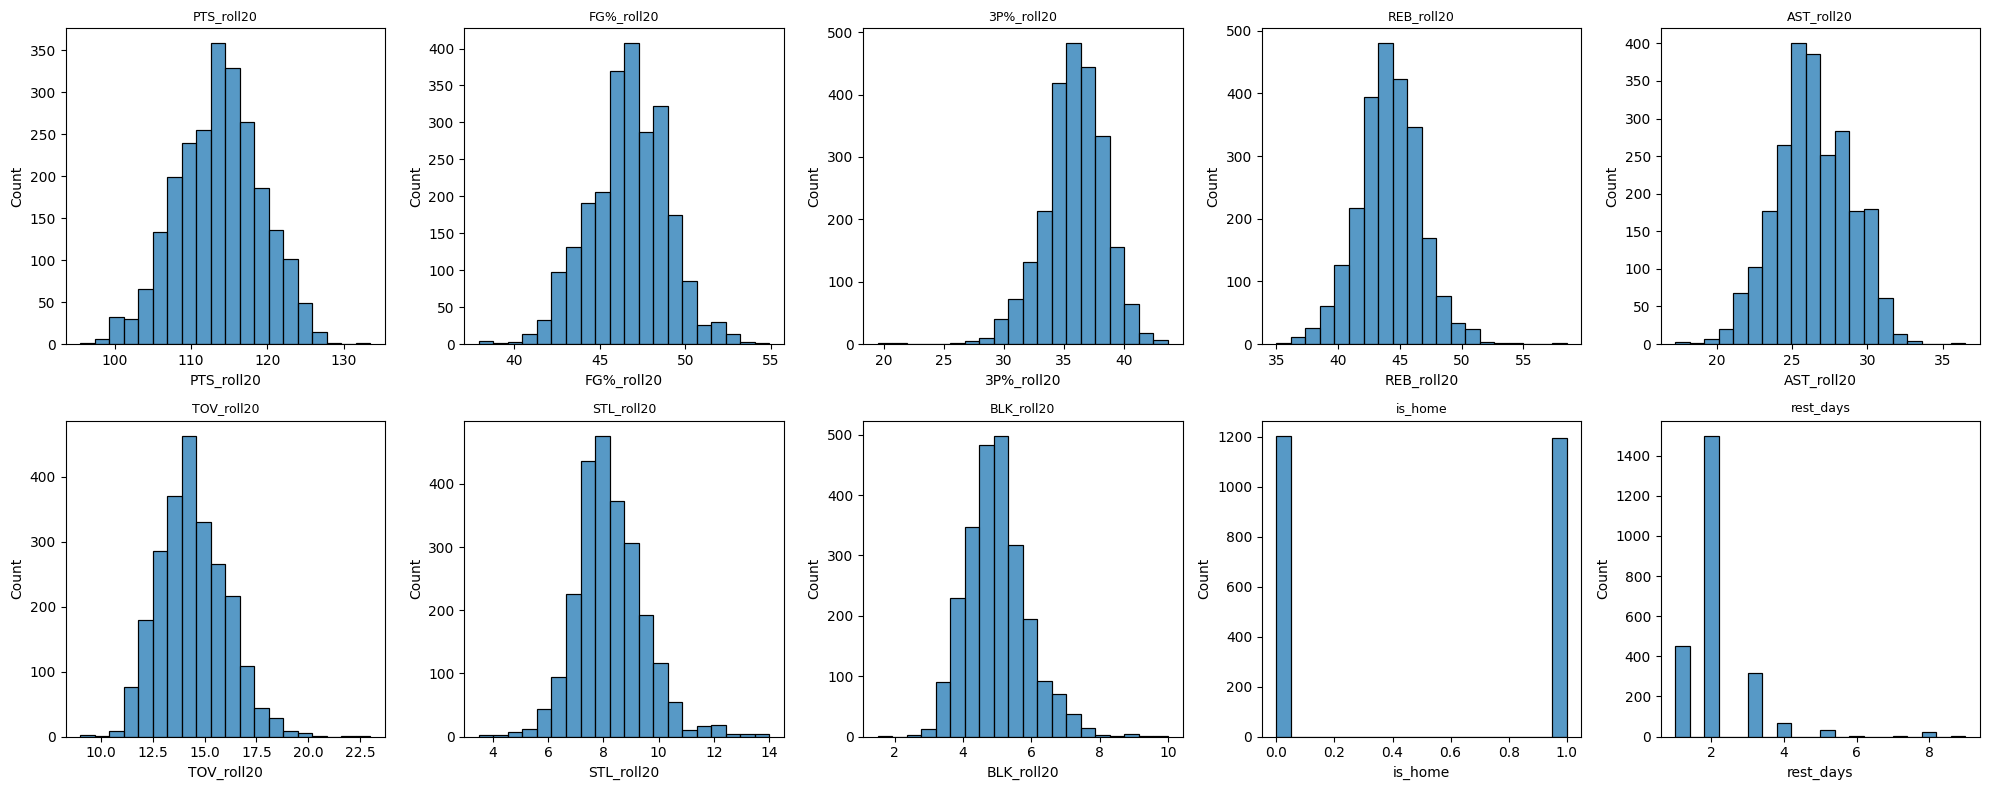

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df_model_final[col].dropna(), bins=20, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

This heatmap shows how each of the final 20-game rolling features relates to win and to each other. FG%_roll20 and TOV_roll20 show the strongest relationships with winning (positive and negative respectively)

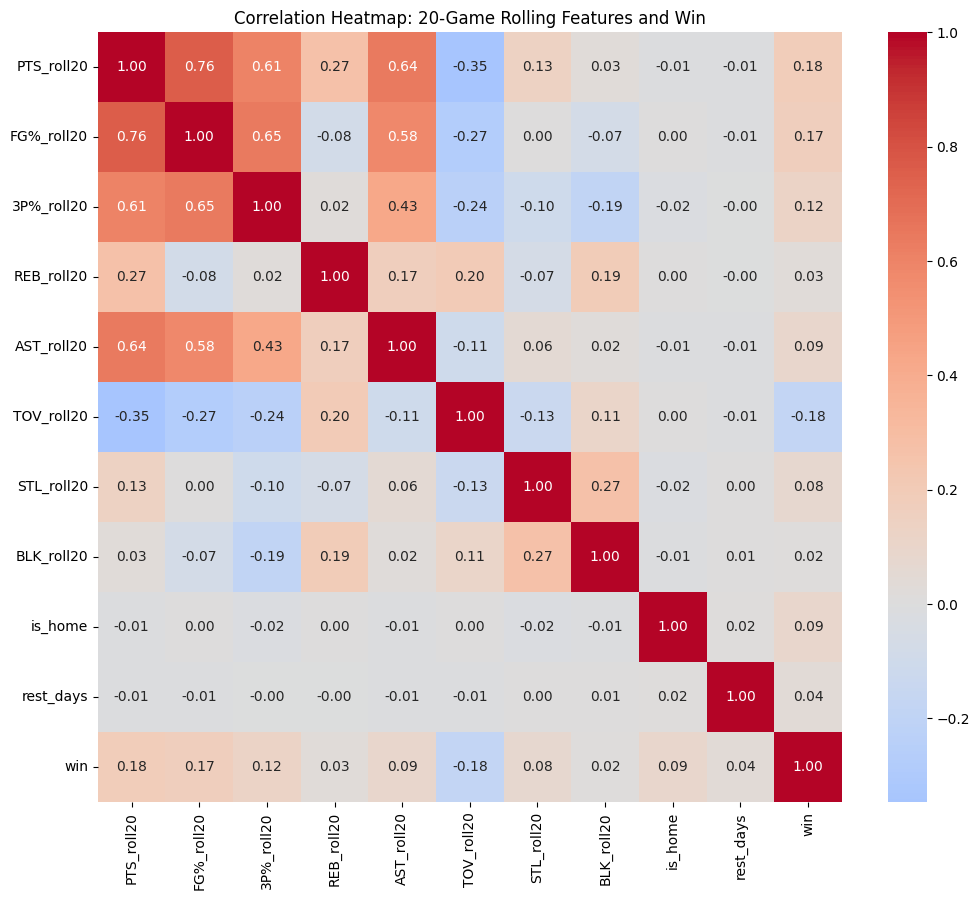

In [17]:
plt.figure(figsize=(12, 10))
corr_cols = feature_cols + ['win']
sns.heatmap(df_model_final[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: 20-Game Rolling Features and Win')
plt.show()

These boxplots compare PTS_roll20 and BLK_roll20 between winning and losing games. PTS_roll20 shows a clear separation between the two groups, one of the model's stronger predictors, while BLK_roll20 shows almost no separation, consistent with its near-zero coefficient, illustrating that not every feature contributes equally to the model's predictions.

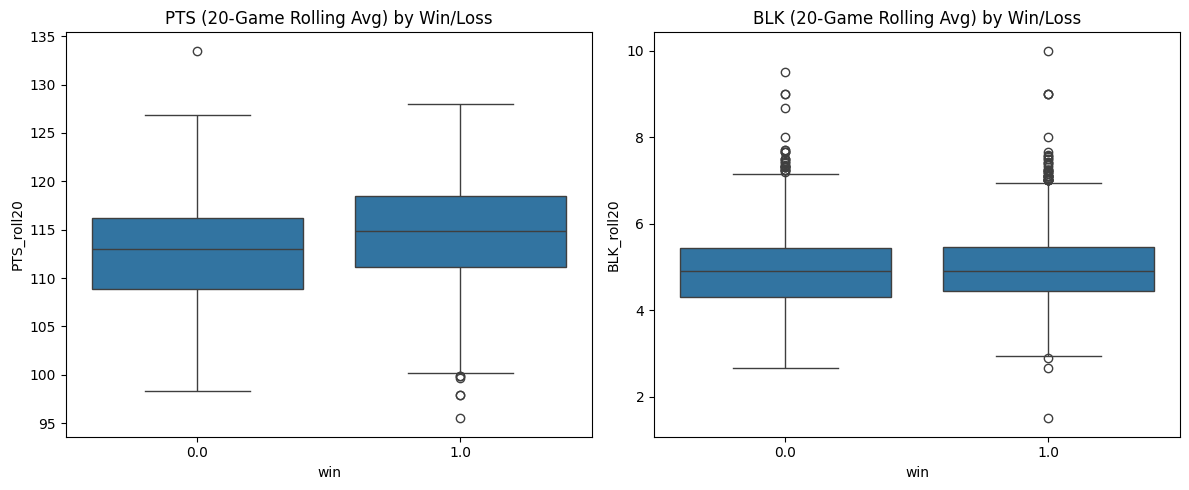

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='win', y='PTS_roll20', data=df_model_final, ax=axes[0])
axes[0].set_title('PTS (20-Game Rolling Avg) by Win/Loss')
sns.boxplot(x='win', y='BLK_roll20', data=df_model_final, ax=axes[1])
axes[1].set_title('BLK (20-Game Rolling Avg) by Win/Loss')
plt.tight_layout()
plt.show()

**FG% vs. AST:** This scatterplot shows the relationship between shooting efficiency and assists, colored by outcome. The two are moderately correlated, teams with better shooting also tend to move the ball well, and wins cluster somewhat toward the upper-right, higher FG% and AST together.

**3P% vs. PTS:** This scatterplot shows three-point shooting against overall scoring. The positive relationship is expected, since made threes directly contribute to points, and wins skew toward the higher end of both, though the overlap between win/loss points shows neither variable alone cleanly separates outcomes.

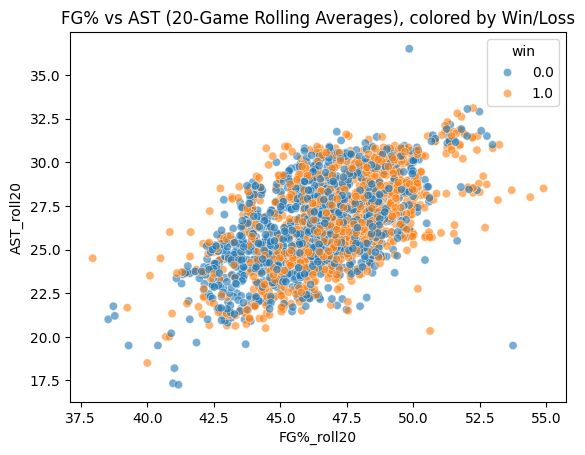

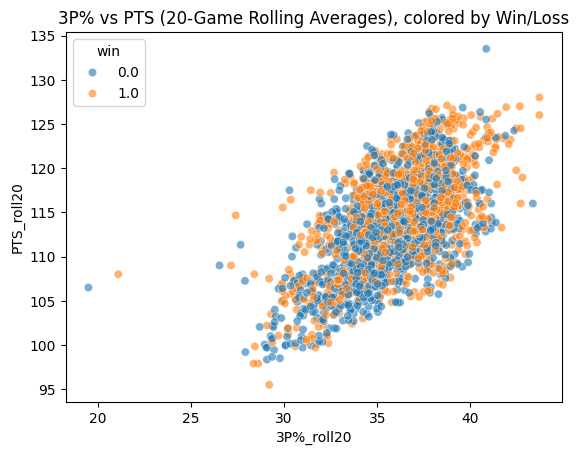

In [19]:
sns.scatterplot(x='FG%_roll20', y='AST_roll20', hue='win', data=df_model_final, alpha=0.6)
plt.title('FG% vs AST (20-Game Rolling Averages), colored by Win/Loss')
plt.show()

sns.scatterplot(x='3P%_roll20', y='PTS_roll20', hue='win', data=df_model_final, alpha=0.6)
plt.title('3P% vs PTS (20-Game Rolling Averages), colored by Win/Loss')
plt.show()

In [55]:
#error analysis
test_df = df_model_final.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = tuned_pred
test_df['actual'] = y_test.values
test_df['FG%_roll20'] = X_test['FG%_roll20'].values

misclassified = test_df[test_df['pred'] != test_df['actual']]
print("Total misclassified:", len(misclassified), "of", len(test_df))

league_avg_fg = X_train['FG%_roll20'].mean()
print("League average FG%_roll20:", league_avg_fg)

misclassified[['date', 'team', 'opponent', 'actual', 'pred', 'FG%_roll20']].head(8)

Total misclassified: 182 of 480
League average FG%_roll20: 46.5544556387182


,date,team,opponent,actual,pred,FG%_roll20
0,2025-03-14,PHI,IND,0.0,1.0,46.300
1,2025-03-14,MIA,BOS,0.0,1.0,46.135
3,2025-03-14,CHA,SAS,1.0,0.0,41.610
4,2025-03-14,TOR,UTA,1.0,0.0,44.475
12,2025-03-15,IND,MIL,0.0,1.0,49.010
13,2025-03-15,NYK,GSW,0.0,1.0,47.820
18,2025-03-15,DET,OKC,0.0,1.0,49.560
20,2025-03-15,DEN,WAS,0.0,1.0,51.595


# Section 4

In [20]:
X = df_model_final[feature_cols]
y = df_model_final['win']

split_idx = int(len(df_model_final) * 0.8)
X_train = df_model_final.iloc[:split_idx][feature_cols]
X_test = df_model_final.iloc[split_idx:][feature_cols]
y_train = df_model_final.iloc[:split_idx]['win']
y_test = df_model_final.iloc[split_idx:]['win']
print(X_train.shape, X_test.shape)

(1920, 10) (480, 10)


In [21]:
print("Full dataset class balance:")
print(df_model_final['win'].value_counts(normalize=True))
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))

Full dataset class balance:
win
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Training set class balance:
win
0.0    0.501042
1.0    0.498958
Name: proportion, dtype: float64

Test set class balance:
win
1.0    0.504167
0.0    0.495833
Name: proportion, dtype: float64


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**


In [23]:
#untuned logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.6208333333333333
ROC-AUC: 0.6637440100006946
              precision    recall  f1-score   support

         0.0       0.66      0.48      0.56       238
         1.0       0.60      0.76      0.67       242

    accuracy                           0.62       480
   macro avg       0.63      0.62      0.61       480
weighted avg       0.63      0.62      0.61       480



In [25]:
coef_df = pd.DataFrame({"Feature": feature_cols, "Coefficient": log_reg.coef_[0]})
print(coef_df.sort_values(by="Coefficient", ascending=False).to_string())

      Feature  Coefficient
1  FG%_roll20     0.265080
8     is_home     0.220826
6  STL_roll20     0.129983
3  REB_roll20     0.124050
0  PTS_roll20     0.091951
9   rest_days     0.064309
7  BLK_roll20    -0.002501
2  3P%_roll20    -0.003568
4  AST_roll20    -0.072711
5  TOV_roll20    -0.283215


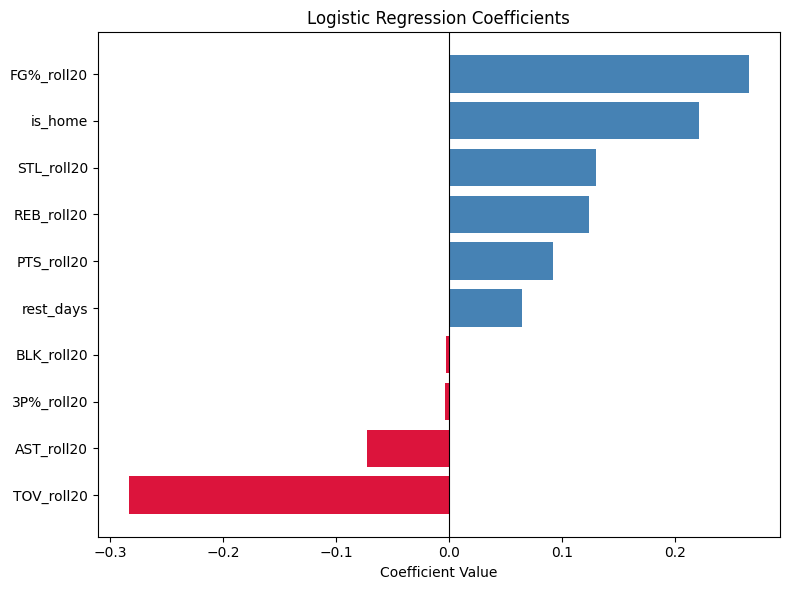

In [26]:
coef_df_sorted = coef_df.sort_values(by="Coefficient")

plt.figure(figsize=(8, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df_sorted['Coefficient']]
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

-used k=5 with TimeSeriesSplit instead of standard randomly shuffled k-fold cross-validation to prevent future games in training data

-chose five folds because the training set contains 1,920 games. Using five folds provides multiple chronological validation periods while maintaining reasonably sized validation sets

In [27]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
fold_acc = []
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    sc = StandardScaler()
    X_tr_scaled = sc.fit_transform(X_tr)
    X_val_scaled = sc.transform(X_val)
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_tr_scaled, y_tr)
    acc = accuracy_score(y_val, model.predict(X_val_scaled))
    fold_acc.append(acc)
    print(f"Fold {i+1}: train={len(tr_idx)} games, val={len(val_idx)} games, accuracy={acc:.4f}")

fold_acc = np.array(fold_acc)
print(f"\nMean CV accuracy: {fold_acc.mean():.4f}")
print(f"Variance: {fold_acc.var():.6f}")
print(f"Std Dev: {fold_acc.std():.4f}")

Fold 1: train=320 games, val=320 games, accuracy=0.5875
Fold 2: train=640 games, val=320 games, accuracy=0.5969
Fold 3: train=960 games, val=320 games, accuracy=0.5938
Fold 4: train=1280 games, val=320 games, accuracy=0.5813
Fold 5: train=1600 games, val=320 games, accuracy=0.5875

Mean CV accuracy: 0.5894
Variance: 0.000030
Std Dev: 0.0054


**Parameter Tuning**

I used grid search (GridSearchCV) to tune three hyperparameters: C, penalty, and class_weight, across an 11-value C range, all penalty types (L1, L2, elasticnet, and none), and both class weighting options, using F1 as the scoring metric.



*   C controls the strength of regularization, the inverse of regularization strength. Smaller values apply stronger regularization, forcing coefficients toward zero and risking underfitting if too strong, while larger values apply weaker regularization, giving the model more flexibility to fit the training data and risking overfitting if too weak
*   penalty determines the type of regularization. L1 can shrink some coefficients completely to zero, effectively removing weak features, while L2 shrinks all coefficients gradually without eliminating any, both act as a check against overfitting, but L1's feature-elimination behavior makes it more aggressive.


*  class_weight adjusts how much the loss function penalizes misclassifying each class.







In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
     'penalty': ['l1', 'l2'], 'solver': ['liblinear'], 'class_weight': [None, 'balanced']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100],
     'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.1, 0.5, 0.9], 'class_weight': [None, 'balanced']},
    {'penalty': [None], 'solver': ['lbfgs'], 'class_weight': [None, 'balanced']},
]

grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1')
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
tuned_pred = best_model.predict(X_test_scaled)
tuned_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("Untuned model parameters:")
print(log_reg.get_params())
print("\nTuned model parameters:")
print(best_model.get_params())

comparison = pd.DataFrame({
    "Model": ["Untuned", "Tuned (F1-scored grid search)"],
    "Accuracy": [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, tuned_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, tuned_proba)]
})
comparison

Untuned model parameters:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Tuned model parameters:
{'C': 0.5, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


,Model,Accuracy,ROC-AUC
0,Untuned,0.620833,0.663744
1,Tuned (F1-scored grid search),0.620833,0.663536


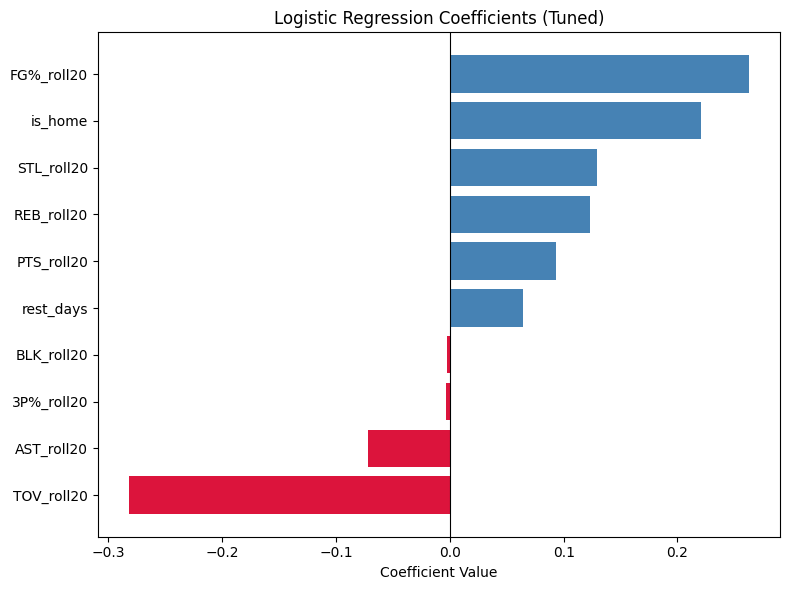

In [29]:
coef_df_tuned = pd.DataFrame({"Feature": feature_cols, "Coefficient": best_model.coef_[0]})
coef_df_tuned_sorted = coef_df_tuned.sort_values(by="Coefficient")

plt.figure(figsize=(8, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df_tuned_sorted['Coefficient']]
plt.barh(coef_df_tuned_sorted['Feature'], coef_df_tuned_sorted['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (Tuned)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

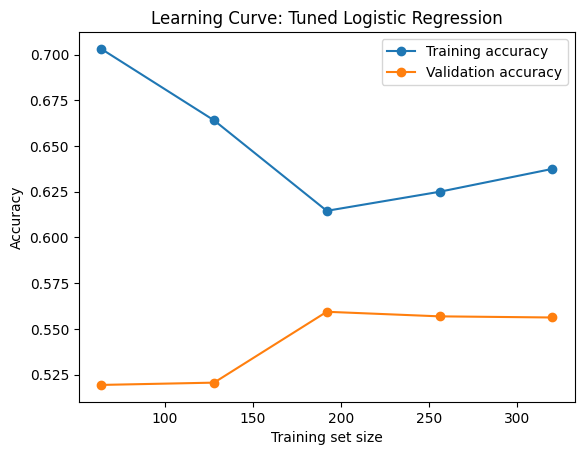

In [30]:
# Learning curves
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=best_model.C, penalty=best_model.penalty, solver='liblinear',
                        class_weight=best_model.class_weight, random_state=42, max_iter=1000),
    X_train_scaled, y_train,
    cv=TimeSeriesSplit(n_splits=5),
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='accuracy'
)

plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training accuracy')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation accuracy')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve: Tuned Logistic Regression')
plt.legend()
plt.show()

**Untuned RF**

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

rf_untuned = RandomForestClassifier(random_state=42)
rf_untuned.fit(X_train, y_train)

rf_pred = rf_untuned.predict(X_test)
rf_proba = rf_untuned.predict_proba(X_test)[:, 1]

print("Untuned Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred))

Untuned Random Forest
Accuracy: 0.5645833333333333
ROC-AUC: 0.6007708868671435
              precision    recall  f1-score   support

         0.0       0.56      0.57      0.56       238
         1.0       0.57      0.56      0.57       242

    accuracy                           0.56       480
   macro avg       0.56      0.56      0.56       480
weighted avg       0.56      0.56      0.56       480



**Tuned RF**

In [32]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 3, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_proba = best_rf.predict_proba(X_test)[:, 1]
print("Best RF parameters:", rf_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, rf_tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_tuned_proba))
print(classification_report(y_test, rf_tuned_pred))

Best RF parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
Accuracy: 0.6104166666666667
ROC-AUC: 0.6455309396485868
              precision    recall  f1-score   support

         0.0       0.62      0.54      0.58       238
         1.0       0.60      0.68      0.64       242

    accuracy                           0.61       480
   macro avg       0.61      0.61      0.61       480
weighted avg       0.61      0.61      0.61       480



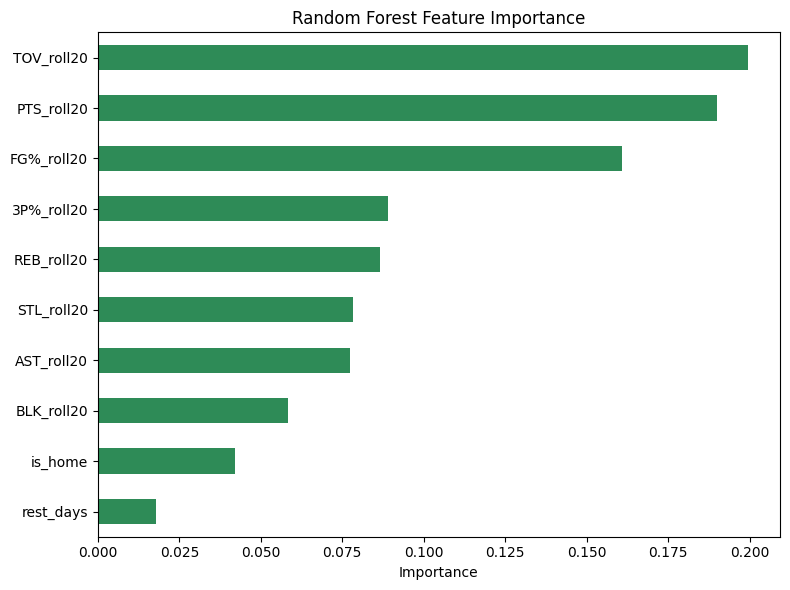

In [33]:
rf_importance = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
rf_importance.plot(kind='barh', color='seagreen')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Untuned XGboost**

In [34]:
from xgboost import XGBClassifier

xgb_untuned = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_untuned.fit(X_train, y_train)
xgb_pred = xgb_untuned.predict(X_test)
xgb_proba = xgb_untuned.predict_proba(X_test)[:, 1]
print("Untuned XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print(classification_report(y_test, xgb_pred))

Untuned XGBoost
Accuracy: 0.5416666666666666
ROC-AUC: 0.5445169803458574
              precision    recall  f1-score   support

         0.0       0.54      0.52      0.53       238
         1.0       0.54      0.57      0.55       242

    accuracy                           0.54       480
   macro avg       0.54      0.54      0.54       480
weighted avg       0.54      0.54      0.54       480



**Tuned XGboost**

In [35]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.3]
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1')
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
xgb_tuned_pred = best_xgb.predict(X_test)
xgb_tuned_proba = best_xgb.predict_proba(X_test)[:, 1]
print("Best XGBoost parameters:", xgb_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, xgb_tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_tuned_proba))
print(classification_report(y_test, xgb_tuned_pred))

Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.6145833333333334
ROC-AUC: 0.6510261129245087
              precision    recall  f1-score   support

         0.0       0.64      0.52      0.57       238
         1.0       0.60      0.71      0.65       242

    accuracy                           0.61       480
   macro avg       0.62      0.61      0.61       480
weighted avg       0.62      0.61      0.61       480



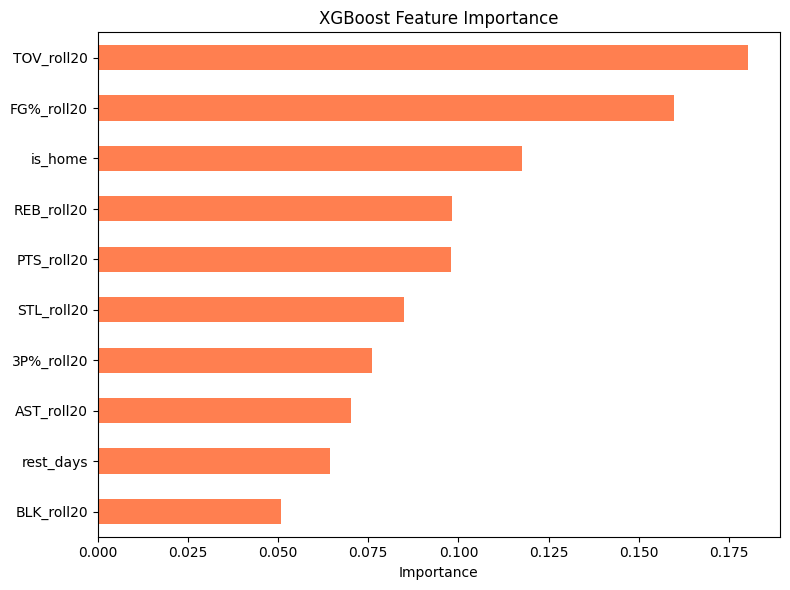

In [36]:
xgb_importance = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
xgb_importance.plot(kind='barh', color='coral')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy (Untuned)": [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    "Accuracy (Tuned)": [accuracy_score(y_test, tuned_pred), accuracy_score(y_test, rf_tuned_pred), accuracy_score(y_test, xgb_tuned_pred)],
    "ROC-AUC (Untuned)": [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, xgb_proba)],
    "ROC-AUC (Tuned)": [roc_auc_score(y_test, tuned_proba), roc_auc_score(y_test, rf_tuned_proba), roc_auc_score(y_test, xgb_tuned_proba)]
})

comparison_table = comparison_table.round(3)
comparison_table

,Model,Accuracy (Untuned),Accuracy (Tuned),ROC-AUC (Untuned),ROC-AUC (Tuned)
0,Logistic Regression,0.621,0.621,0.664,0.664
1,Random Forest,0.565,0.610,0.601,0.646
2,XGBoost,0.542,0.615,0.545,0.651


# Section 5

**Naive Baseline Comparison**

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

df_2025['prev_win'] = df_2025.groupby('team')['win'].shift(1)
df_persist = df_2025[['gameid', 'date', 'team', 'win', 'prev_win']].dropna(subset=['prev_win']).reset_index(drop=True)
df_persist = df_persist.sort_values('date').reset_index(drop=True)

sp = int(len(df_persist) * 0.8)
persist_true = df_persist.iloc[sp:]['win']
persist_pred = df_persist.iloc[sp:]['prev_win']

persistence_acc = accuracy_score(persist_true, persist_pred)
persistence_precision = precision_score(persist_true, persist_pred)
persistence_recall = recall_score(persist_true, persist_pred)
persistence_f1 = f1_score(persist_true, persist_pred)

print(f"Persistence baseline -> Accuracy: {persistence_acc:.4f}, Precision: {persistence_precision:.4f}, Recall: {persistence_recall:.4f}, F1: {persistence_f1:.4f}")
print(f"Tuned Logistic Regression -> Accuracy: {accuracy_score(y_test, tuned_pred):.4f}, Precision: {precision_score(y_test, tuned_pred):.4f}, Recall: {recall_score(y_test, tuned_pred):.4f}, F1: {f1_score(y_test, tuned_pred):.4f}")

Persistence baseline -> Accuracy: 0.5864, Precision: 0.5861, Recall: 0.5885, F1: 0.5873
Tuned Logistic Regression -> Accuracy: 0.6208, Precision: 0.5980, Recall: 0.7562, F1: 0.6679


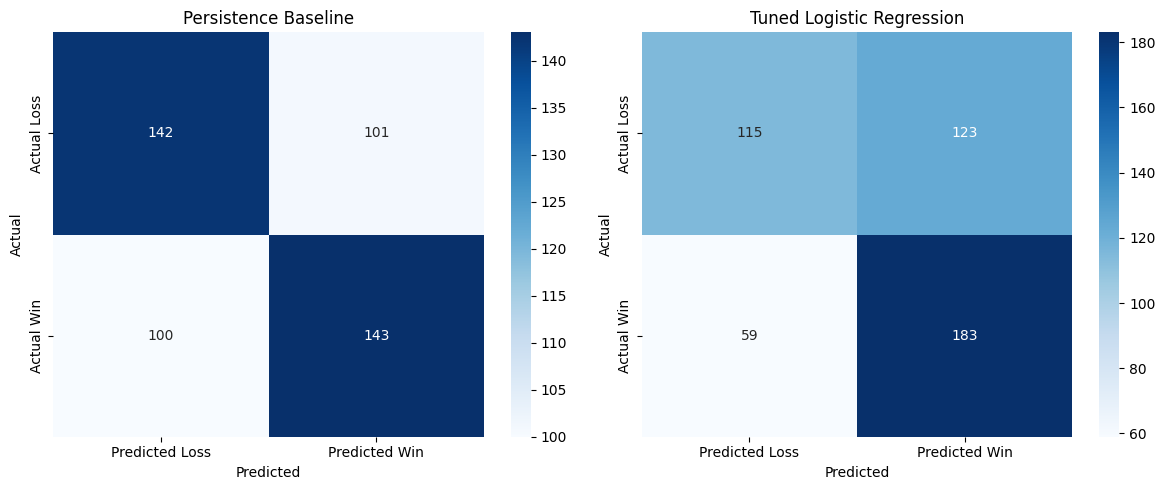

In [40]:
from sklearn.metrics import confusion_matrix

cm_persist = confusion_matrix(persist_true, persist_pred)
cm_logreg = confusion_matrix(y_test, tuned_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_persist, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[0])
axes[0].set_title('Persistence Baseline')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[1])
axes[1].set_title('Tuned Logistic Regression')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

**Tuned vs Untuned Logistic Regression Model Compariso**n

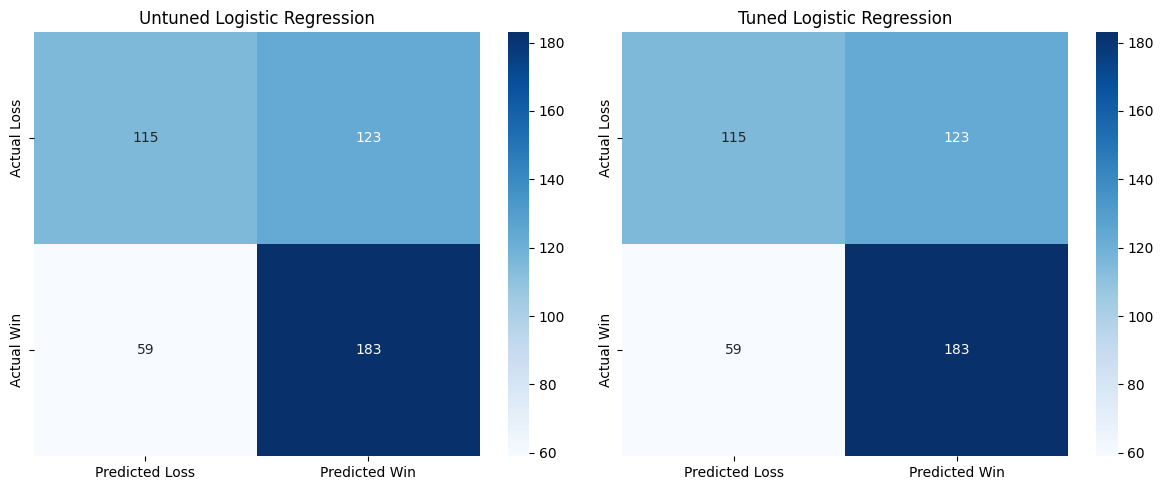

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_untuned = confusion_matrix(y_test, y_pred_log)
cm_tuned = confusion_matrix(y_test, tuned_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_untuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[0])
axes[0].set_title('Untuned Logistic Regression')
axes[0].set_ylabel
axes[0].set_xlabel

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[1])
axes[1].set_title('Tuned Logistic Regression')
axes[1].set_ylabel
axes[1].set_xlabel

plt.tight_layout()
plt.show()

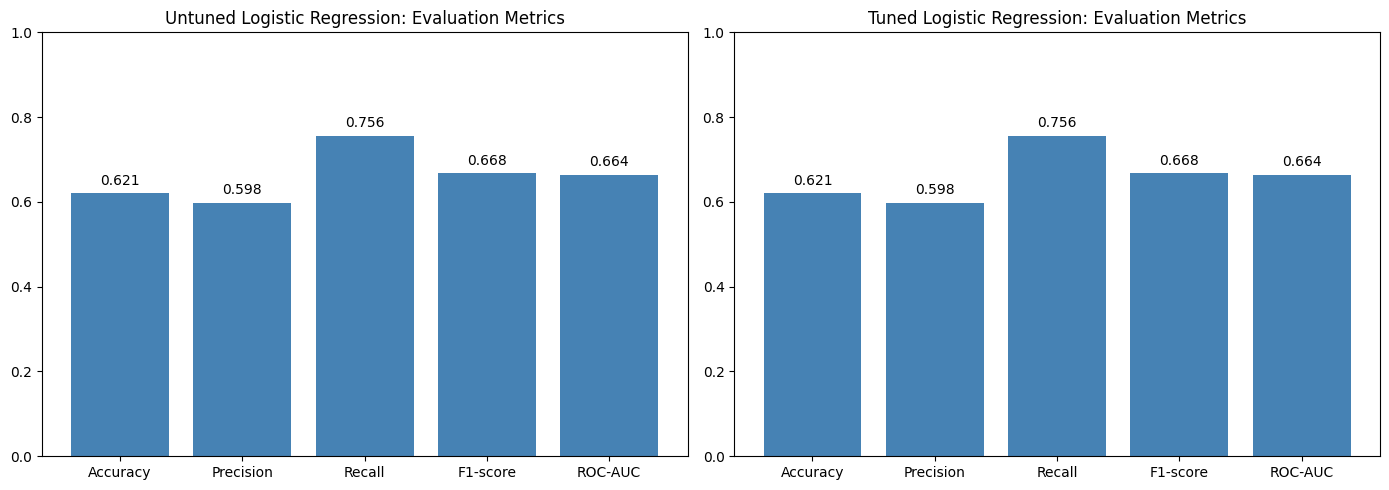

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

untuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_log), 'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log), 'F1-score': f1_score(y_test, y_pred_log),
    'ROC-AUC': roc_auc_score(y_test, y_proba_log)
}
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, tuned_pred), 'Precision': precision_score(y_test, tuned_pred),
    'Recall': recall_score(y_test, tuned_pred), 'F1-score': f1_score(y_test, tuned_pred),
    'ROC-AUC': roc_auc_score(y_test, tuned_proba)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(untuned_metrics.keys(), untuned_metrics.values(), color='steelblue')
axes[0].set_ylim(0, 1)
for i, (k, v) in enumerate(untuned_metrics.items()):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0].set_title('Untuned Logistic Regression: Evaluation Metrics')

axes[1].bar(tuned_metrics.keys(), tuned_metrics.values(), color='steelblue')
axes[1].set_ylim(0, 1)
for i, (k, v) in enumerate(tuned_metrics.items()):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1].set_title('Tuned Logistic Regression: Evaluation Metrics')
plt.tight_layout()
plt.show()

**Tuned logistic regression vs RF**

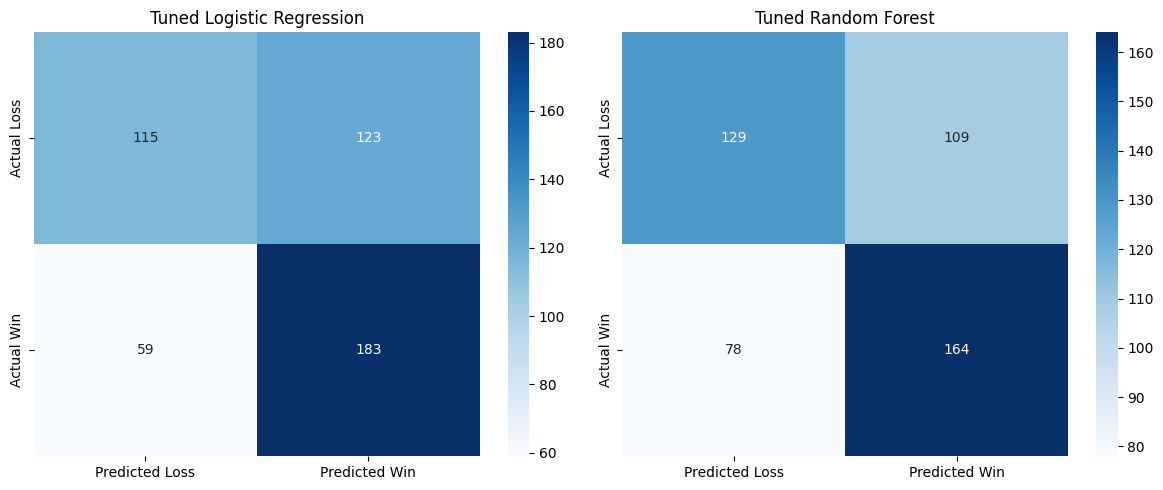

In [43]:
from sklearn.metrics import confusion_matrix

cm_logreg = confusion_matrix(y_test, tuned_pred)
cm_rf = confusion_matrix(y_test, rf_tuned_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[0])
axes[0].set_title('Tuned Logistic Regression')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[1])
axes[1].set_title('Tuned Random Forest')
plt.tight_layout()
plt.show()

**Tuned logistic regression vs XGboost**

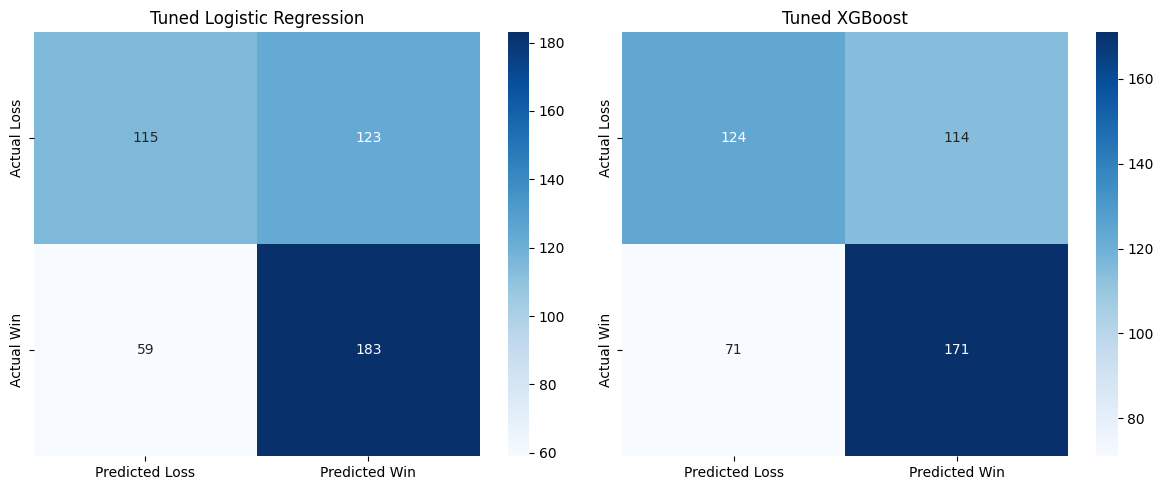

In [45]:
cm_xgb = confusion_matrix(y_test, xgb_tuned_pred)



fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[0])
axes[0].set_title('Tuned Logistic Regression')
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'], ax=axes[1])
axes[1].set_title('Tuned XGBoost')
plt.tight_layout()
plt.show()

**Evaluation metrics for all models**

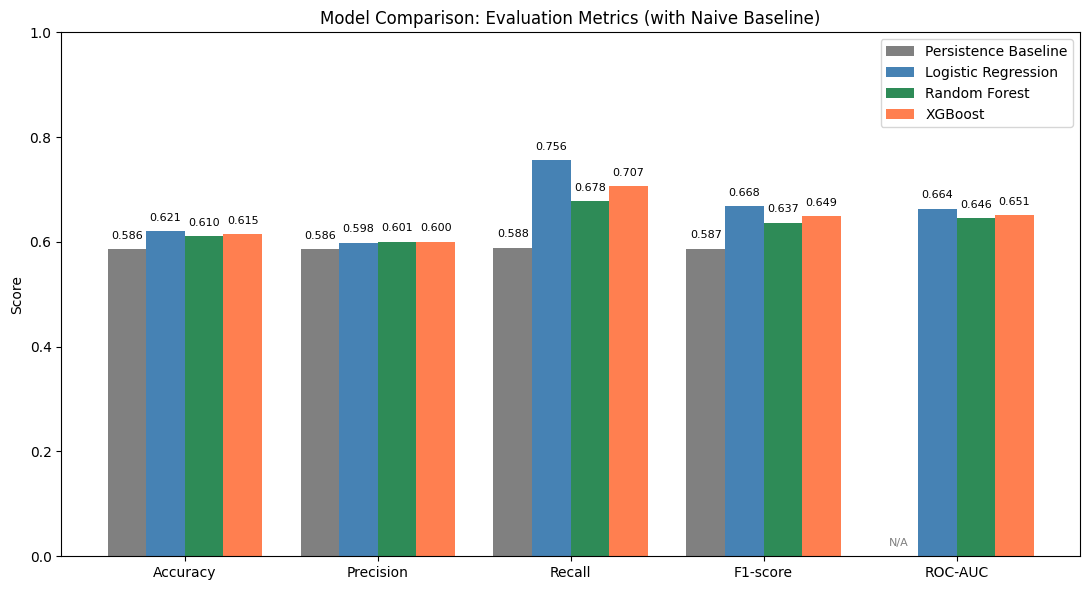

In [47]:
import numpy as np

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

persist_vals = [persistence_acc, persistence_precision, persistence_recall, persistence_f1, None]
logreg_vals = [accuracy_score(y_test, tuned_pred), precision_score(y_test, tuned_pred),
               recall_score(y_test, tuned_pred), f1_score(y_test, tuned_pred),
               roc_auc_score(y_test, tuned_proba)]
rf_vals = [accuracy_score(y_test, rf_tuned_pred), precision_score(y_test, rf_tuned_pred),
           recall_score(y_test, rf_tuned_pred), f1_score(y_test, rf_tuned_pred),
           roc_auc_score(y_test, rf_tuned_proba)]
xgb_vals = [accuracy_score(y_test, xgb_tuned_pred), precision_score(y_test, xgb_tuned_pred),
            recall_score(y_test, xgb_tuned_pred), f1_score(y_test, xgb_tuned_pred),
            roc_auc_score(y_test, xgb_tuned_proba)]

x = np.arange(len(metrics_names))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
bars0 = ax.bar(x - 1.5*width, [v if v is not None else 0 for v in persist_vals], width, label='Persistence Baseline', color='gray')
bars1 = ax.bar(x - 0.5*width, logreg_vals, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + 0.5*width, rf_vals, width, label='Random Forest', color='seagreen')
bars3 = ax.bar(x + 1.5*width, xgb_vals, width, label='XGBoost', color='coral')

for bars, vals in [(bars0, persist_vals), (bars1, logreg_vals), (bars2, rf_vals), (bars3, xgb_vals)]:
    for bar, v in zip(bars, vals):
        if v is None:
            ax.text(bar.get_x() + bar.get_width()/2, 0.02, 'N/A', ha='center', fontsize=8, color='gray')
        else:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{v:.3f}', ha='center', fontsize=8)

ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Evaluation Metrics (with Naive Baseline)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_table = pd.DataFrame({
    "Model": ["Persistence Baseline", "Logistic Regression (Untuned)", "Logistic Regression (Tuned)",
              "Random Forest (Tuned)", "XGBoost (Tuned)"],
    "Accuracy": [
        persistence_acc,
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, tuned_pred),
        accuracy_score(y_test, rf_tuned_pred),
        accuracy_score(y_test, xgb_tuned_pred)
    ],
    "Precision": [
        persistence_precision,
        precision_score(y_test, y_pred_log),
        precision_score(y_test, tuned_pred),
        precision_score(y_test, rf_tuned_pred),
        precision_score(y_test, xgb_tuned_pred)
    ],
    "Recall": [
        persistence_recall,
        recall_score(y_test, y_pred_log),
        recall_score(y_test, tuned_pred),
        recall_score(y_test, rf_tuned_pred),
        recall_score(y_test, xgb_tuned_pred)
    ],
    "F1-score": [
        persistence_f1,
        f1_score(y_test, y_pred_log),
        f1_score(y_test, tuned_pred),
        f1_score(y_test, rf_tuned_pred),
        f1_score(y_test, xgb_tuned_pred)
    ],
    "ROC-AUC": [
        None,  # persistence has no probability output
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, tuned_proba),
        roc_auc_score(y_test, rf_tuned_proba),
        roc_auc_score(y_test, xgb_tuned_proba)
    ]
})

comparison_table = comparison_table.round(3)
comparison_table

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Persistence Baseline,0.586,0.586,0.588,0.587,NaN
1,Logistic Regression (Untuned),0.621,0.598,0.756,0.668,0.664
2,Logistic Regression (Tuned),0.621,0.598,0.756,0.668,0.664
3,Random Forest (Tuned),0.610,0.601,0.678,0.637,0.646
4,XGBoost (Tuned),0.615,0.600,0.707,0.649,0.651


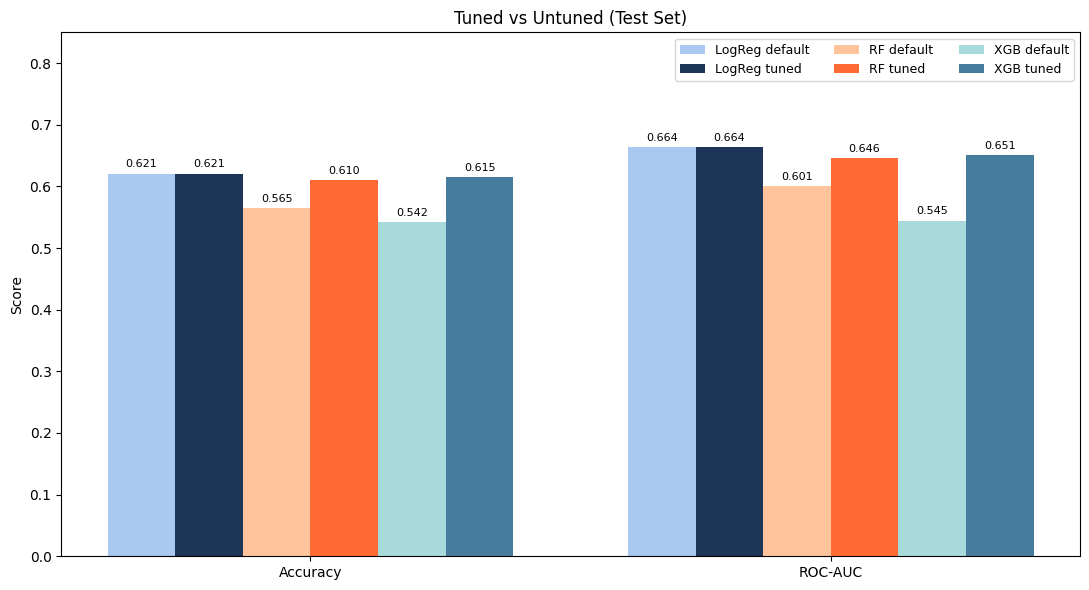

In [49]:
import matplotlib.pyplot as plt
import numpy as np

metrics_names = ['Accuracy', 'ROC-AUC']

logreg_untuned = [accuracy_score(y_test, y_pred_log), roc_auc_score(y_test, y_proba_log)]
logreg_tuned   = [accuracy_score(y_test, tuned_pred), roc_auc_score(y_test, tuned_proba)]
rf_untuned_vals = [accuracy_score(y_test, rf_pred), roc_auc_score(y_test, rf_proba)]
rf_tuned_vals   = [accuracy_score(y_test, rf_tuned_pred), roc_auc_score(y_test, rf_tuned_proba)]
xgb_untuned_vals = [accuracy_score(y_test, xgb_pred), roc_auc_score(y_test, xgb_proba)]
xgb_tuned_vals   = [accuracy_score(y_test, xgb_tuned_pred), roc_auc_score(y_test, xgb_tuned_proba)]

x = np.arange(len(metrics_names))
width = 0.13

fig, ax = plt.subplots(figsize=(11, 6))
bars = [
    ax.bar(x - 2.5*width, logreg_untuned, width, label='LogReg default', color='#A9C9F0'),
    ax.bar(x - 1.5*width, logreg_tuned, width, label='LogReg tuned', color='#1D3557'),
    ax.bar(x - 0.5*width, rf_untuned_vals, width, label='RF default', color='#FFC49B'),
    ax.bar(x + 0.5*width, rf_tuned_vals, width, label='RF tuned', color='#FF6B35'),
    ax.bar(x + 1.5*width, xgb_untuned_vals, width, label='XGB default', color='#A8DADC'),
    ax.bar(x + 2.5*width, xgb_tuned_vals, width, label='XGB tuned', color='#457B9D'),
]

for group in bars:
    for bar in group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('Tuned vs Untuned (Test Set)')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score

# Set random seed for reproducibility
np.random.seed(42)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [51]:
# Define models (using each model's tuned hyperparameters)
model_logreg = LogisticRegression(**grid.best_params_, random_state=42, max_iter=5000)
model_rf = best_rf
model_xgb = best_xgb

# Define cross-validation strategy
# TimeSeriesSplit instead of RepeatedStratifiedKFold, since this is time-series data
# and shuffled/repeated folds would let future games leak into training
cv_strategy = TimeSeriesSplit(n_splits=5)

# Get cross-validation scores (ROC-AUC, my primary comparison metric)
log_scores = cross_val_score(model_logreg, X_train_scaled, y_train, cv=cv_strategy, scoring='roc_auc')
rf_scores = cross_val_score(model_rf, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
xgb_scores = cross_val_score(model_xgb, X_train, y_train, cv=cv_strategy, scoring='roc_auc')

print(f"Logistic Regression - Mean ROC-AUC: {log_scores.mean():.4f} (+/- {log_scores.std():.4f})")
print(f"Random Forest - Mean ROC-AUC: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"XGBoost - Mean ROC-AUC: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

print(f"\nLogistic Regression - Variance: {log_scores.var():.6f}")
print(f"Random Forest - Variance: {rf_scores.var():.6f}")
print(f"XGBoost - Variance: {xgb_scores.var():.6f}")

print(f"\nNumber of paired scores: {len(log_scores)}")
print(f"Observed difference in means (RF - LogReg): {rf_scores.mean() - log_scores.mean():.4f}")
print(f"Observed difference in means (XGB - LogReg): {xgb_scores.mean() - log_scores.mean():.4f}")
print(f"Observed difference in means (XGB - RF): {xgb_scores.mean() - rf_scores.mean():.4f}")

Logistic Regression - Mean ROC-AUC: 0.6288 (+/- 0.0130)
Random Forest - Mean ROC-AUC: 0.6132 (+/- 0.0168)
XGBoost - Mean ROC-AUC: 0.6040 (+/- 0.0257)

Logistic Regression - Variance: 0.000168
Random Forest - Variance: 0.000282
XGBoost - Variance: 0.000661

Number of paired scores: 5
Observed difference in means (RF - LogReg): -0.0156
Observed difference in means (XGB - LogReg): -0.0248
Observed difference in means (XGB - RF): -0.0093


# **Statistical Analysis**

## Wilcoxon Signed-Rank Test

A non-parametric alternative to the paired t-test. It does not assume normality of the differences, making it a safer choice than the t-test when the sample size is small.



*   Assumption: The differences are symmetric around the median (weaker than the t-test's normality assumption).
*   H0: The median difference in ROC-AUC between the two models is 0


*   H1: The median difference in ROC-AUC is not 0
*   Why I'm using this over the paired t-test: my cross-validation only produced 5 fold scores per model, well below the n ≥ 30 threshold needed for the Central Limit Theorem to justify the paired t-test's normality assumption. Wilcoxon doesn't require that assumption, making it the more appropriate significance test for my project.

In [52]:
comparisons = [
    ("RF vs Logistic Regression", rf_scores, log_scores),
    ("XGBoost vs Logistic Regression", xgb_scores, log_scores),
    ("XGBoost vs Random Forest", xgb_scores, rf_scores)
]

for label, scores_a, scores_b in comparisons:
    w_stat, p_value_wilcoxon = wilcoxon(scores_a, scores_b)

    print(f"=== Wilcoxon Signed-Rank Test: {label} ===")
    print(f"W-statistic: {w_stat:.4f}")
    print(f"p-value: {p_value_wilcoxon:.6f}")
    print(f"Conclusion at alpha=0.05: ", end="")
    if p_value_wilcoxon < 0.05:
        print("REJECT H0 - The difference is statistically significant.")
    else:
        print("FAIL TO REJECT H0 - No significant difference detected.")
    print()

=== Wilcoxon Signed-Rank Test: RF vs Logistic Regression ===
W-statistic: 0.0000
p-value: 0.062500
Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.

=== Wilcoxon Signed-Rank Test: XGBoost vs Logistic Regression ===
W-statistic: 1.0000
p-value: 0.125000
Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.

=== Wilcoxon Signed-Rank Test: XGBoost vs Random Forest ===
W-statistic: 4.0000
p-value: 0.437500
Conclusion at alpha=0.05: FAIL TO REJECT H0 - No significant difference detected.



# McNemar's Test

McNemar's test is specifically designed for comparing two classifiers on the same test set. It looks at the **disagreement** between the two models.

- It uses a 2x2 contingency table:
  - b: samples that Model A got right but Model B got wrong
  - c: samples that Model B got right but Model A got wrong
- **H0**: Both models have the same error rate (b = c).
- **H1**: The models have different error rates.
- **Test statistic**: chi-squared = (|b - c| - 1)^2 / (b + c) (with continuity correction)

In [53]:
def mcnemar_test(y_true, preds_a, preds_b, label):
    correct_a = (preds_a == y_true.values)
    correct_b = (preds_b == y_true.values)
    b = np.sum(correct_a & ~correct_b)
    c = np.sum(~correct_a & correct_b)
    print(f"--- {label} ---")
    if b + c == 0:
        print("Both models made identical predictions, no test possible.\n")
        return
    chi2_stat = (abs(b - c) - 1)**2 / (b + c)
    p_val = 1 - chi2.cdf(chi2_stat, df=1)
    print(f"b (model A right, B wrong): {b}, c (model A wrong, B right): {c}")
    print(f"Chi-squared statistic: {chi2_stat:.4f}")
    print(f"p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("Conclusion: REJECT H0 - the models have significantly different error rates.\n")
    else:
        print("Conclusion: FAIL TO REJECT H0 - no significant difference in error rates.\n")

mcnemar_test(y_test, rf_tuned_pred, tuned_pred, "RF vs LogReg")
mcnemar_test(y_test, xgb_tuned_pred, tuned_pred, "XGB vs LogReg")
mcnemar_test(y_test, xgb_tuned_pred, rf_tuned_pred, "XGB vs RF")

--- RF vs LogReg ---
b (model A right, B wrong): 35, c (model A wrong, B right): 40
Chi-squared statistic: 0.2133
p-value: 0.6442
Conclusion: FAIL TO REJECT H0 - no significant difference in error rates.

--- XGB vs LogReg ---
b (model A right, B wrong): 39, c (model A wrong, B right): 42
Chi-squared statistic: 0.0494
p-value: 0.8241
Conclusion: FAIL TO REJECT H0 - no significant difference in error rates.

--- XGB vs RF ---
b (model A right, B wrong): 22, c (model A wrong, B right): 20
Chi-squared statistic: 0.0238
p-value: 0.8774
Conclusion: FAIL TO REJECT H0 - no significant difference in error rates.



# Bootstrap Confidence Intervals for the Difference in Accuracy

Bootstrap resampling allows us to estimate the confidence interval for the difference in performance without parametric assumptions.

- We resample the paired scores with replacement (10,000 times).
- For each resample, we compute the mean difference.
- The 2.5th and 97.5th percentiles give the 95% CI.
- If the 95% CI does not contain 0, that's evidence of a real, significant difference between the two models.

In [54]:
# Bootstrap confidence intervals for the difference in ROC-AUC
n_bootstrap = 10000
np.random.seed(42)

comparisons = [
    ("RF vs Logistic Regression", rf_scores, log_scores),
    ("XGBoost vs Logistic Regression", xgb_scores, log_scores),
    ("XGBoost vs Random Forest", xgb_scores, rf_scores)
]

for label, scores_a, scores_b in comparisons:
    differences = scores_a - scores_b
    observed_diff = differences.mean()

    bootstrap_diffs = []
    for _ in range(n_bootstrap):
        # Resample with replacement from the paired differences
        sample = np.random.choice(differences, size=len(differences), replace=True)
        bootstrap_diffs.append(sample.mean())

    bootstrap_diffs = np.array(bootstrap_diffs)

    # Calculate confidence intervals
    ci_95_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_95_upper = np.percentile(bootstrap_diffs, 97.5)
    ci_99_lower = np.percentile(bootstrap_diffs, 0.5)
    ci_99_upper = np.percentile(bootstrap_diffs, 99.5)

    print(f"=== Bootstrap Confidence Intervals: {label} (ROC-AUC Difference) ===")
    print(f"\nObserved mean difference: {observed_diff:.4f}")
    print(f"95% CI: [{ci_95_lower:.4f}, {ci_95_upper:.4f}]")
    print(f"99% CI: [{ci_99_lower:.4f}, {ci_99_upper:.4f}]")
    print(f"\nDoes the 95% CI contain 0? {'Yes' if ci_95_lower <= 0 <= ci_95_upper else 'No'}")
    if ci_95_lower > 0:
        print(f"Conclusion: {label.split(' vs ')[0]} is significantly better.")
    elif ci_95_upper < 0:
        print(f"Conclusion: {label.split(' vs ')[1]} is significantly better.")
    else:
        print("Conclusion: No significant difference detected.")
    print()

=== Bootstrap Confidence Intervals: RF vs Logistic Regression (ROC-AUC Difference) ===

Observed mean difference: -0.0156
95% CI: [-0.0246, -0.0071]
99% CI: [-0.0274, -0.0046]

Does the 95% CI contain 0? No
Conclusion: Logistic Regression is significantly better.

=== Bootstrap Confidence Intervals: XGBoost vs Logistic Regression (ROC-AUC Difference) ===

Observed mean difference: -0.0248
95% CI: [-0.0385, -0.0095]
99% CI: [-0.0393, -0.0062]

Does the 95% CI contain 0? No
Conclusion: Logistic Regression is significantly better.

=== Bootstrap Confidence Intervals: XGBoost vs Random Forest (ROC-AUC Difference) ===

Observed mean difference: -0.0093
95% CI: [-0.0252, 0.0046]
99% CI: [-0.0288, 0.0079]

Does the 95% CI contain 0? Yes
Conclusion: No significant difference detected.



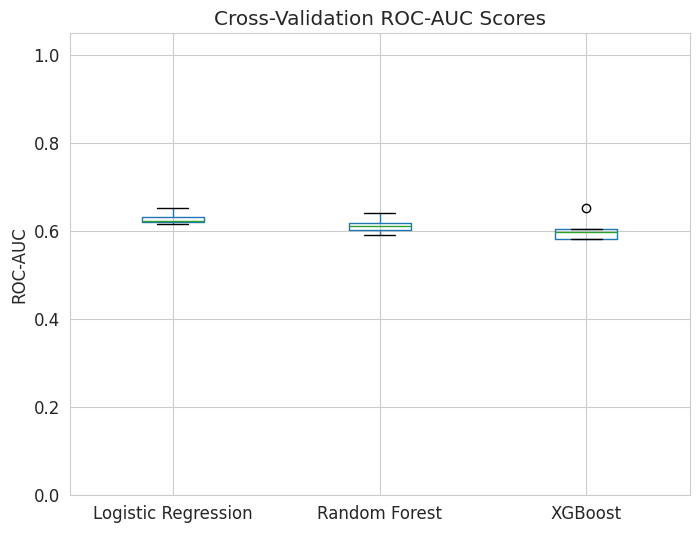

In [58]:
#Box plots of CV scores for all three models
plt.figure(figsize=(8, 6))
scores_df = pd.DataFrame({
    'Logistic Regression': log_scores,
    'Random Forest': rf_scores,
    'XGBoost': xgb_scores
})
scores_df.boxplot()
plt.title('Cross-Validation ROC-AUC Scores')
plt.ylabel('ROC-AUC')
plt.ylim([0, 1.05])
plt.show()

In [59]:
# 95% Confidence Intervals for model comparison, matching class methodology
n_bootstrap = 10000
np.random.seed(42)

comparisons = [
    ("RF vs Logistic Regression", rf_scores, log_scores),
    ("XGBoost vs Logistic Regression", xgb_scores, log_scores),
    ("XGBoost vs Random Forest", xgb_scores, rf_scores)
]

results = []
for label, scores_a, scores_b in comparisons:
    differences = scores_a - scores_b
    observed_diff = differences.mean()

    bootstrap_diffs = np.array([
        np.random.choice(differences, size=len(differences), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    ci_95_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_95_upper = np.percentile(bootstrap_diffs, 97.5)

    print(f"=== {label} ===")
    print(f"Observed mean difference: {observed_diff:.4f}")
    print(f"95% CI: [{ci_95_lower:.4f}, {ci_95_upper:.4f}]")
    print(f"Does the 95% CI contain 0? {'Yes' if ci_95_lower <= 0 <= ci_95_upper else 'No'}\n")
    results.append((label, observed_diff, ci_95_lower, ci_95_upper))

=== RF vs Logistic Regression ===
Observed mean difference: -0.0156
95% CI: [-0.0246, -0.0071]
Does the 95% CI contain 0? No

=== XGBoost vs Logistic Regression ===
Observed mean difference: -0.0248
95% CI: [-0.0385, -0.0095]
Does the 95% CI contain 0? No

=== XGBoost vs Random Forest ===
Observed mean difference: -0.0093
95% CI: [-0.0252, 0.0046]
Does the 95% CI contain 0? Yes



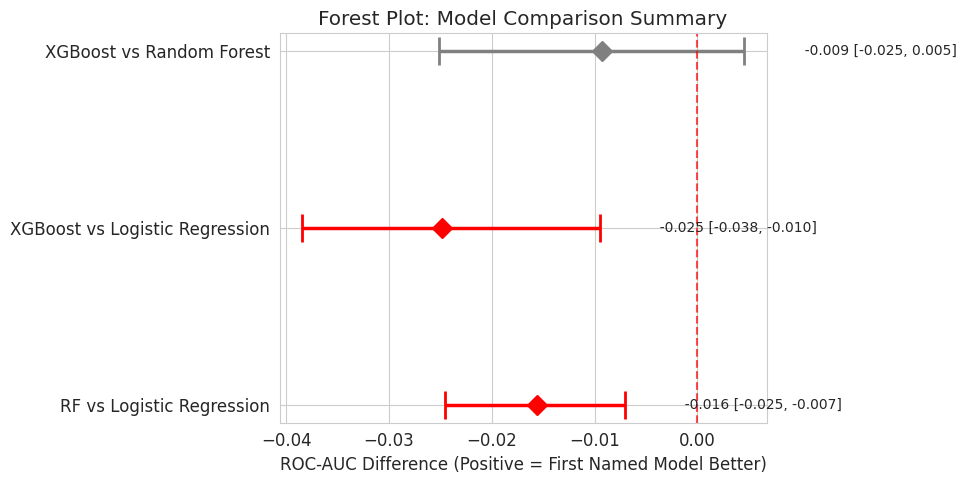

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, (label, mean, lower, upper) in enumerate(results):
    color = 'green' if lower > 0 else ('red' if upper < 0 else 'gray')
    ax.errorbar(mean, i, xerr=[[mean - lower], [upper - mean]],
                fmt='D', color=color, ecolor=color, capsize=10, capthick=2,
                markersize=10, elinewidth=2.5)
    ax.text(upper + 0.005, i, f"  {mean:.3f} [{lower:.3f}, {upper:.3f}]", va='center', fontsize=10)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(len(results)))
ax.set_yticklabels([r[0] for r in results])
ax.set_xlabel('ROC-AUC Difference (Positive = First Named Model Better)')
ax.set_title('Forest Plot: Model Comparison Summary')
plt.tight_layout()
plt.show()

In [61]:
import sklearn, numpy, pandas, scipy, xgboost, matplotlib, seaborn, sys

print("Python:", sys.version.split()[0])
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("xgboost:", xgboost.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("Random seed used throughout: 42")

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
scipy: 1.16.3
xgboost: 3.3.0
matplotlib: 3.10.0
seaborn: 0.13.2
Random seed used throughout: 42
